In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
df = pd.read_csv("final_matched_dataset.csv")

df.head()

,name,matched_name,ingredients,category,portion,calories,protein,fat,carb
0,chicken handi,chicken,"Chicken, Onion, Tomatoes, Garlic, Ginger paste...",meat,100 g,166.0,21.4,1.79,0.0
1,chicken mandi,chicken,"Chicken, Basmati Rice, Water, Onion, Garlic, G...",meat,100 g,166.0,21.4,1.79,0.0
2,sticky chicken,chicken,"Chicken drumsticks, Soy Sauce, Honey, Olive Oi...",meat,100 g,166.0,21.4,1.79,0.0
3,chicken congee,chicken,"Chicken, Salt, Pepper, Ginger Cordial, Ginger,...",meat,100 g,166.0,21.4,1.79,0.0
4,chicken karaage,chicken,"Chicken, Ginger, Garlic, Soy sauce, Sake, Gran...",meat,100 g,166.0,21.4,1.79,0.0


In [ ]:
print(df.isnull().sum())

name            5
matched_name    0
ingredients     0
category        0
portion         0
calories        0
protein         0
fat             0
carb            0
dtype: int64


In [ ]:
df.dropna(inplace=True)

print(df.shape)

(13824, 9)


In [ ]:
df.isnull().sum()

,0
name,0
matched_name,0
ingredients,0
category,0
portion,0
calories,0
protein,0
fat,0
carb,0


In [ ]:
df["text"] = (

    df["name"].astype(str)

    + " "

    + df["ingredients"].astype(str)

    + " portion "

    + df["portion"].astype(str)

    + " category "

    + df["category"].astype(str)

)

In [ ]:
df[["text", "calories"]].head()

,text,calories
0,"chicken handi Chicken, Onion, Tomatoes, Garlic...",166.0
1,"chicken mandi Chicken, Basmati Rice, Water, On...",166.0
2,"sticky chicken Chicken drumsticks, Soy Sauce, ...",166.0
3,"chicken congee Chicken, Salt, Pepper, Ginger C...",166.0
4,"chicken karaage Chicken, Ginger, Garlic, Soy s...",166.0


In [ ]:
df["label"] = pd.qcut(
    df["calories"],
    q=3,
    labels=[0,1,2]
)

df["label"] = df["label"].astype(int)

print(df["label"].value_counts())

label
0    4756
2    4588
1    4480
Name: count, dtype: int64


In [ ]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(df["text"])

In [ ]:
sequences = tokenizer.texts_to_sequences(df["text"])

In [ ]:
X = pad_sequences(
    sequences,
    maxlen=80,
    padding="post"
)

In [ ]:
y = np.array(df["label"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)

test_dataset = TensorDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
class GRUModel(nn.Module):

    def __init__(self):

        super(GRUModel, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=10000,
            embedding_dim=64
        )

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc1 = nn.Linear(64, 32)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(32, 3)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        hidden = hidden[-1]

        x = self.fc1(hidden)

        x = self.relu(x)

        out = self.fc2(x)

        return out

In [ ]:
model = GRUModel()

print(model)

GRUModel(
  (embedding): Embedding(10000, 64)
  (gru): GRU(64, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 7

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

print(f"Epoch {epoch+1} Loss: {avg_loss}")

Epoch 7 Loss: 0.5075332732558939


In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.numpy())

        all_labels.extend(batch_y.numpy())

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

Accuracy: 0.7103074141048824


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.747174,0.769312,0.758081,945.000000
1,0.633369,0.662959,0.647826,899.000000
2,0.753231,0.695983,0.723476,921.000000
accuracy,0.710307,0.710307,0.710307,0.710307
macro avg,0.711258,0.709418,0.709795,2765.000000
weighted avg,0.712189,0.710307,0.710707,2765.000000


In [ ]:
all_confidences = []

model.eval()

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        probs = torch.softmax(outputs, dim=1)

        conf = probs.max(dim=1).values

        all_confidences.extend(conf.numpy())

In [ ]:
results_df = pd.DataFrame({

    "Real": all_labels,

    "Predicted": all_preds,

    "Confidence": all_confidences

})

results_df.head()

,Real,Predicted,Confidence
0,2,2,0.996632
1,1,2,0.958115
2,2,2,0.457321
3,2,2,0.997698
4,0,0,0.989171


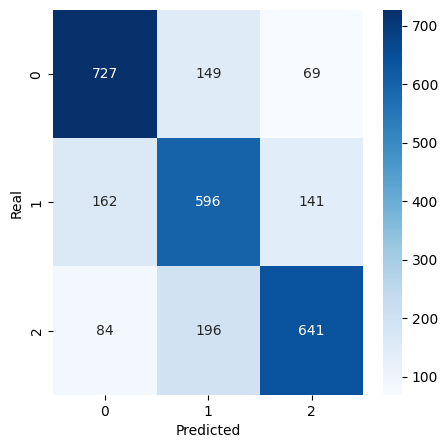

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.show()

In [ ]:
print(df["label"].value_counts())

label
0    4756
2    4588
1    4480
Name: count, dtype: int64


In [ ]:
def predict_food(food_text):

    model.eval()

    sequence = tokenizer.texts_to_sequences([food_text])

    padded = pad_sequences(
        sequence,
        maxlen=50,
        padding="post"
    )

    tensor_input = torch.tensor(
        padded,
        dtype=torch.long
    )

    with torch.no_grad():

        output = model(tensor_input)

        probs = torch.softmax(output, dim=1)

        prediction = torch.argmax(probs, dim=1).item()

        confidence = probs.max().item()

    labels_map = {
        0: "Low Calories",
        1: "Medium Calories",
        2: "High Calories"
    }

    print("Prediction:", labels_map[prediction])

    print("Confidence:", round(confidence, 4))

In [ ]:
predict_food(
    "fried chicken burger with cheese and fries"
)

Prediction: High Calories
Confidence: 0.9254


In [ ]:
predict_food(
    "green salad with cucumber and tomato"
)

Prediction: Low Calories
Confidence: 0.8606


In [ ]:
predict_food(
    "chocolate cake with cream"
)

Prediction: High Calories
Confidence: 0.8891


In [ ]:
predict_food(
    "grilled chicken sandwich with mayo"
)

Prediction: Medium Calories
Confidence: 0.5312


In [ ]:
def predict_food_with_calories(food_text):

    model.eval()

    sequence = tokenizer.texts_to_sequences([food_text])

    padded = pad_sequences(
        sequence,
        maxlen=80,
        padding="post"
    )

    tensor_input = torch.tensor(
        padded,
        dtype=torch.long
    )

    with torch.no_grad():

        output = model(tensor_input)

        probs = torch.softmax(output, dim=1)

        prediction = torch.argmax(probs, dim=1).item()

        confidence = probs.max().item()

    labels_map = {
        0: ("Low Calories", "100 - 300 kcal"),
        1: ("Medium Calories", "300 - 600 kcal"),
        2: ("High Calories", "600+ kcal")
    }

    category, calories_range = labels_map[prediction]

    print("Prediction:", category)

    print("Estimated Calories:", calories_range)

    print("Confidence:", round(confidence, 4))

In [ ]:
predict_food_with_calories(
    "chicken burger with fries"
)

Prediction: High Calories
Estimated Calories: 600+ kcal
Confidence: 0.7988
